<a href="https://colab.research.google.com/github/RomdhaneNamji/Breast-Cancer-Detection-Using-Machine-Learning-Project/blob/main/breast_cancer_detection_scientific_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



### **Comparative Study of Machine Learning Algorithms for Breast Cancer Classification**



### Project idea and motivation

This notebook presents a **Scientific Python workflow** using the Breast Cancer Wisconsin Diagnostic dataset: [Kaggle — Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

The dataset contains **569 patient records** and **30 numeric features** derived from digitised FNA (fine needle aspirate) images.

Target variable:
- `0` = benign tumor
- `1` = malignant tumor

**The goal is to build a binary classifier that predicts whether a breast tumor is malignant or benign from computed tumor-cell features.**

### Research question
Can we use Python to build a clear and reproducible workflow that separates malignant from benign tumors, while also comparing the computational cost of different methods?

### Workflow

1. Load the real dataset.
2. Clean non-informative columns and encode the target.
3. Explore class balance, feature distributions, and correlations.
4. Split data into train/test sets with stratification.
5. Compare simple models using repeated cross-validation.
6. Evaluate the selected model on a held-out test set.
7. Analyze runtime and efficiency using cross-validation timing.
8. Compare Pandas and NumPy performance for numerical aggregation.
9. Add a small scaling simulation to test performance on larger resampled data.
10. Add simple integrity tests for reproducibility.


## 1. Library imports



- **NumPy**: numerical arrays and vectorized operations.
- **Pandas**: tabular data loading, cleaning, and aggregation.
- **Matplotlib / Seaborn**: data visualization.
- **Scikit-learn**: preprocessing, cross-validation, model training, and evaluation.
- **time.perf_counter**: runtime measurement for efficiency analysis.

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Machine learning tools
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#For modeling and evaluation
import time


# Reproducibility
np.random.seed(42)

## 2.  Loading & Cleaning the Dataset

We use the real Kaggle CSV (loaded via `kagglehub`).  
Two columns are immediately dropped: `id` (meaningless identifier) and `Unnamed: 32` (entirely empty).  
The text target `M / B` is encoded as `1 / 0` so every column is numeric.

In [ ]:
# Load from Kaggle
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
df   = pd.read_csv(path + "/data.csv")

# Drop useless columns
drop_cols = [c for c in ["id", "Unnamed: 32"] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Binary Encoding the target variable M → 1 (Malignant), B → 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Checking the dataset
print(f"Shape           : {df.shape}   (rows × columns)")
print(f"Missing values  : {df.isnull().sum().sum()}")


# Verify we have exactly 30 numeric features + 1 target
assert df.shape[1] == 31,           "Expected 31 columns (30 features + diagnosis)"
assert df.isnull().sum().sum() == 0, "Dataset should have no missing values"

df.describe().T.head(10)   # show stats for the first 10 features

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Shape           : (569, 31)   (rows × columns)
Missing values  : 0


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.00000,0.00000,0.00000,1.0000,1.0000
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040


### **Understanding the Features**

The dataset contains 30 numeric features. These are derived from 10 fundamental real-valued characteristics of the cell nuclei found in the images:

1.  **Radius**: Mean of distances from center to points on the perimeter.
2.  **Texture**: Standard deviation of gray-scale values.
3.  **Perimeter**: Total distance around the boundary of the nucleus.
4.  **Area**: Total surface area of the nucleus.
5.  **Smoothness**: Local variation in radius lengths.
6.  **Compactness**: Computed as `perimeter^2 / area - 1.0`.
7.  **Concavity**: Severity of concave portions of the contour.
8.  **Concave points**: Number of concave portions of the contour.
9.  **Symmetry**: Measures how balanced the nucleus shape is.
10. **Fractal dimension**: "Coastline approximation" - 1.

For each of these 10 characteristics, three values are recorded:
*   **Mean**: The average value.
*   **SE (Standard Error)**: The standard error of the mean.
*   **Worst/Largest**: The mean of the three largest values.

This explains why we have 30 columns (10 base features × 3 types of measurements).

## 3.  Exploratory Data Analysis (EDA)

Three questions we answer visually:
1. **Are the classes balanced?** pie chart visualization
2. **Which features are correlated with diagnosis?** correlation heatmap
3. **Do key features separate the two classes?** box plots


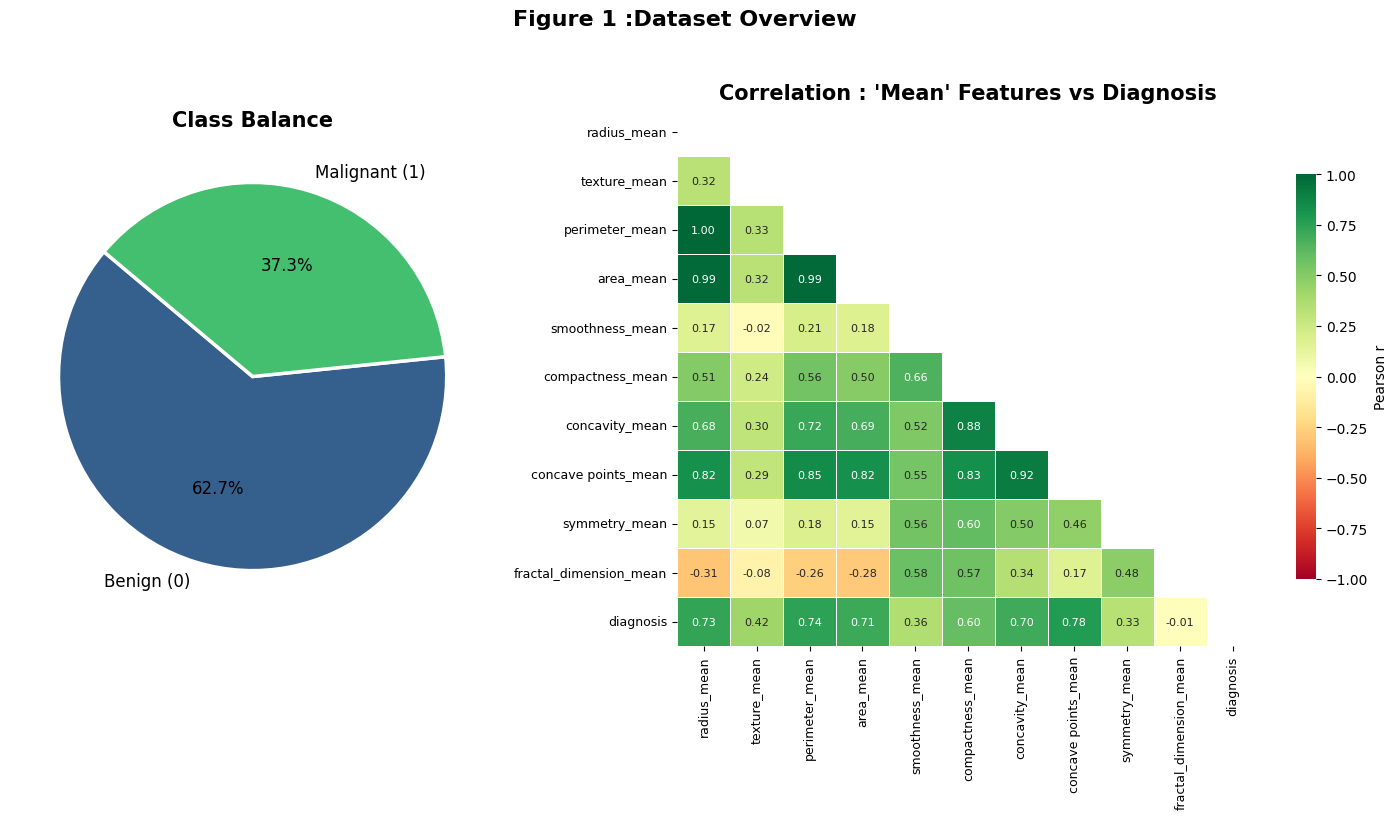

In [ ]:
#  Figure 1 : Class balance + Correlation heatmap
fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5], wspace=0.3)

# Left panel: class balance pie chart
ax0     = fig.add_subplot(gs[0])
counts  = df["diagnosis"].value_counts().sort_index()
pie_colors = plt.cm.viridis(np.linspace(0.3, 0.7, 2))

wedges, texts, autotexts = ax0.pie(
    counts,
    labels      = ["Benign (0)", "Malignant (1)"],
    autopct     = "%1.1f%%",
    startangle  = 140,
    colors      = pie_colors,
    wedgeprops  = {"edgecolor": "white", "linewidth": 2.5},
    textprops   = {"fontsize": 12},
)
ax0.set_title("Class Balance", fontsize=15, fontweight="bold")

# Right panel: Correlation heatmap (only 'mean' features + diagnosis)
ax1          = fig.add_subplot(gs[1])
mean_cols    = [c for c in df.columns if "mean" in c]
corr         = df[mean_cols + ["diagnosis"]].corr()
mask         = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr, mask=mask,
    annot       = True, fmt=".2f",
    cmap        = "RdYlGn",
    vmin=-1, vmax=1,
    linewidths  = 0.4,
    annot_kws   = {"size": 8},
    cbar_kws    = {"shrink": 0.75, "label": "Pearson r"},
    ax          = ax1,
)
ax1.set_title("Correlation : 'Mean' Features vs Diagnosis", fontsize=15, fontweight="bold")
ax1.tick_params(axis="x", labelsize=9)
ax1.tick_params(axis="y", labelsize=9)

fig.suptitle("Figure 1 :Dataset Overview", fontsize=16, fontweight="bold", y=1.02)
plt.show()


### **Interpretation**

*   **Class Balance**: The pie chart shows a distribution of ~63% benign and ~37% malignant cases. While there is a slight imbalance, it is not severe enough to require specialized resampling techniques, though we will use stratified splitting to maintain these proportions.
*   **Multicollinearity**: The heatmap reveals extremely high correlations (near 1.0) between `radius`, `perimeter`, and `area`. This is expected as these are geometrically related. We should keep this in mind as redundant features can sometimes affect the coefficients of linear models.
*   **Diagnostic Potential**: Several 'mean' features show strong positive correlations with the diagnosis, suggesting they will be significant predictors in our classification models.

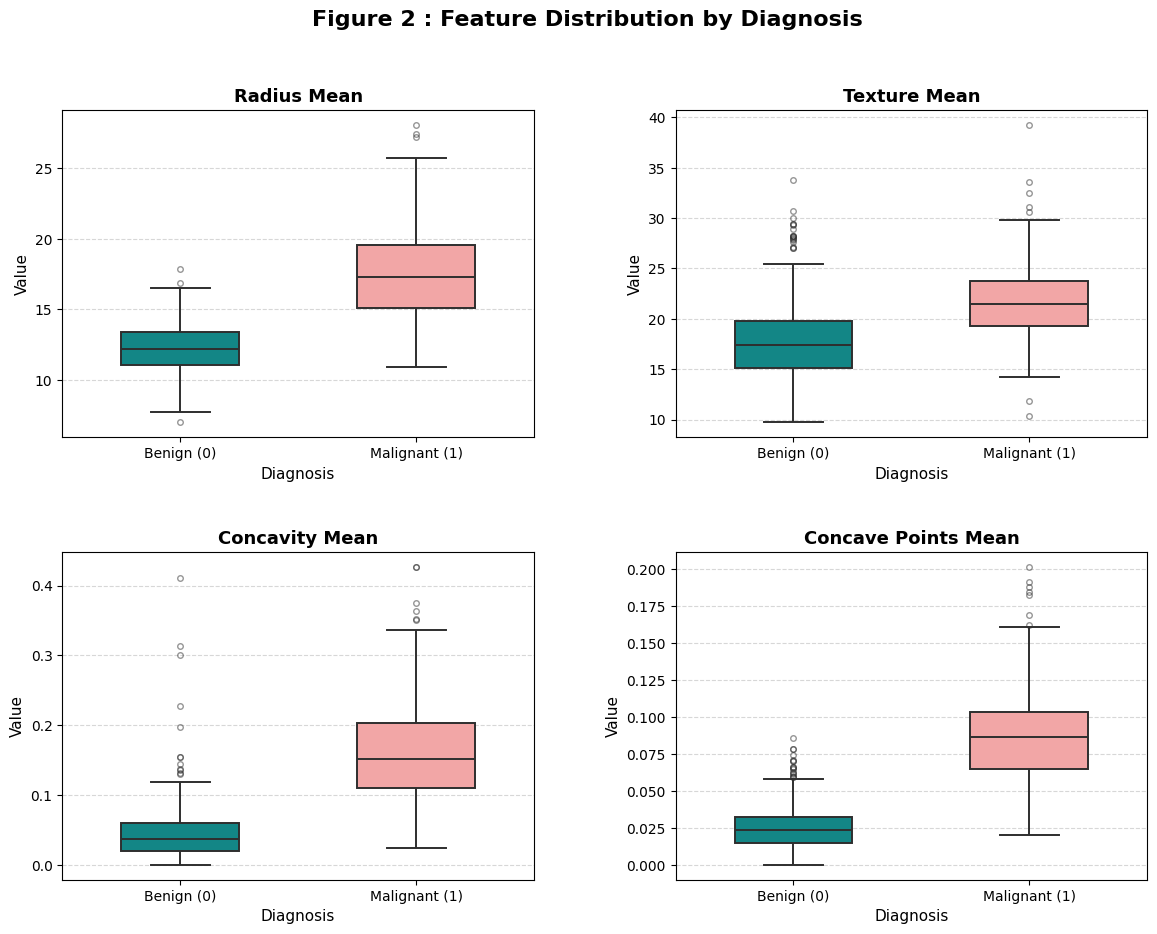

In [ ]:
# Figure 2 Box plots
key_features = [
    "radius_mean",
    "texture_mean",
    "concavity_mean",
    "concave points_mean",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figure 2 : Feature Distribution by Diagnosis", fontsize=16, fontweight="bold")
plt.subplots_adjust(wspace=0.3, hspace=0.35)
palette = ["#009999", "#ff9999"]

for ax, feature in zip(axes.flatten(), key_features):
    sns.boxplot(
        data    = df,
        x       = "diagnosis",
        y       = feature,
        hue     = "diagnosis",
        palette = palette,
        legend  = False,
        width   = 0.5,
        linewidth = 1.4,
        flierprops = {"marker": "o", "markersize": 4, "alpha": 0.5},
        ax      = ax,
    )

    # axis labels
    ax.set_title(feature.replace("_", " ").title(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Diagnosis", fontsize=11)
    ax.set_ylabel("Value", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign (0)", "Malignant (1)"], fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

**Key observation:** malignant tumours generally have higher `radius_mean`, `concavity_mean`, and `concave points_mean`. These variables show clear visual separation between the two diagnostic groups.


## 4. Model Training & Cross-Validation

We compare three common classifiers:


*  ***Logistic Regression***: strong baseline for tabular binary classification

*   ***K-Nearest Neighbors***: distance-based model

*   ***Random Forest***: ensemble model that often captures nonlinear structure


### Evaluation strategy
We use **Repeated Stratified K-Fold** (5 splits × 10 repeats = 50 evaluations per model) to get a robust, low-variance estimate of each model's true performance.

In [ ]:
# Separate features (X) and target variable (y)
X = df.drop(columns=["diagnosis"])   # 30 numeric features
y = df["diagnosis"]                  # 0 = Benign, 1 = Malignant

# Train / test split (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")


Training set : 455 samples
Test set     : 114 samples


In [ ]:
# Definition of models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()), # standardization
        ("model",  LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()), # standardization
        ("model",  KNeighborsClassifier(n_neighbors=7)),
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ]),
}
models

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', LogisticRegression(max_iter=2000, random_state=42))]),
 'KNN': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', KNeighborsClassifier(n_neighbors=7))]),
 'Random Forest': Pipeline(steps=[('model',
                  RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                         random_state=42))])}

**Cross validation**

Cross-validation (CV) evaluates how well a machine learning model generalizes to unseen data. It repeatedly splits the dataset into training and validation folds, then averages the results to give a more reliable performance estimate than a single train/test split.

In [ ]:
#  Cross-validation loop
# Define the cross-validation strategy: 5 splits, repeated 10 times, ensuring class balance within each fold.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# Define the scoring metrics to evaluate the models.
scoring = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

rows = []
# Iterate through each model defined in the 'models' dictionary.
for name, pipe in models.items():
    t_start    = time.perf_counter() # Record start time for performance measurement.
    # Perform cross-validation for the current model. n_jobs=-1 uses all available CPU cores.
    cv_scores  = cross_validate(pipe, X_train, y_train,
                                cv=cv, scoring=scoring, n_jobs=-1)
    cv_runtime = time.perf_counter() - t_start # Calculate the total time taken for CV.

    # Store the average scores and runtime for the current model.
    rows.append({
        "Model"        : name,
        "Accuracy"     : np.mean(cv_scores["test_accuracy"]),
        "Precision"    : np.mean(cv_scores["test_precision"]),
        "Recall"       : np.mean(cv_scores["test_recall"]),
        "F1"           : np.mean(cv_scores["test_f1"]),
        "ROC-AUC"      : np.mean(cv_scores["test_roc_auc"]),
        "Acc ± std"    : np.std(cv_scores["test_accuracy"]),
        "CV time (s)"  : round(cv_runtime, 3),
    })
    # Print a summary for the current model.
    print(f"  {name:<22}  AUC={np.mean(cv_scores['test_roc_auc']):.4f}  "
          f"F1={np.mean(cv_scores['test_f1']):.4f}  [{cv_runtime:.1f}s]")

# Convert the results into a Pandas DataFrame and sort by ROC-AUC.
results_df = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
print()
# Set 'Model' as the index for better presentation.
results_df.set_index("Model")

  Logistic Regression     AUC=0.9936  F1=0.9621  [9.7s]
  KNN                     AUC=0.9858  F1=0.9521  [2.2s]
  Random Forest           AUC=0.9880  F1=0.9394  [46.9s]



,Accuracy,Precision,Recall,F1,ROC-AUC,Acc ± std,CV time (s)
Model,,,,,,,
Logistic Regression,0.972308,0.978757,0.947059,0.962119,0.993550,0.016036,9.696
Random Forest,0.955604,0.954373,0.927059,0.939449,0.988024,0.023565,46.914
KNN,0.965934,0.990851,0.917647,0.952107,0.985841,0.017617,2.206


**Interpretation of Metrics:**

ROC-AUC is the most useful summary metric here because it measures how well a model separates benign and malignant cases across classification thresholds. Recall is also important because, in a diagnostic setting, missing malignant tumours is more serious than incorrectly flagging a benign case.


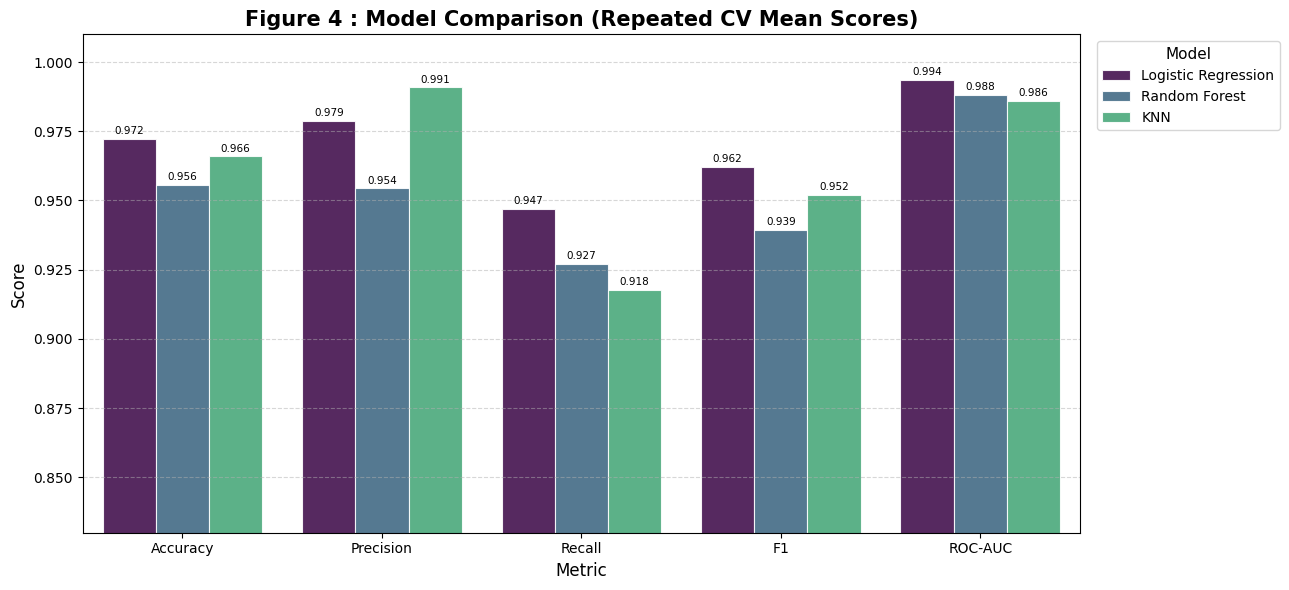

In [ ]:
# CV performance comparison
# Melt the DataFrame so seaborn can plot all metrics in one call
melted = results_df.melt(
    id_vars   = ["Model"],
    value_vars = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name  = "Metric",
    value_name= "Score",
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data    = melted,
    x       = "Metric",
    y       = "Score",
    hue     = "Model",
    palette = ["#440154", "#31688e", "#35b779"],
    alpha   = 0.88,
    edgecolor = "white",
    linewidth = 0.8,
    ax      = ax,
)

ax.set_ylim(0.83, 1.01)           # zoom in to show meaningful differences
ax.set_title("Figure 4 : Model Comparison (Repeated CV Mean Scores)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.legend(title="Model", fontsize=10, title_fontsize=11,
          bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate each bar with its value
for patch in ax.patches:
    h = patch.get_height()
    if h > 0.01:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            h + 0.001,
            f"{h:.3f}",
            ha="center", va="bottom",
            fontsize=7.5, color="black",
        )

plt.tight_layout() # adjusts the padding
plt.show()

## 5.  Best Model : Test Set Evaluation

We pick the model with the highest mean ROC-AUC from cross-validation (in our case it's the logistic regression), then fit it on the **full training set** and evaluate **once** on the held-out test set.


In [ ]:
# Select the best performing model based on the highest mean ROC-AUC from cross-validation
best_name  = results_df.iloc[0]["Model"]
best_pipe  = models[best_name]
best_pipe.fit(X_train, y_train)

# Predict on the held-out test set
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]   # probability of class 1

print(f"Best model : {best_name}")
print(f"Test AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

Best model : Logistic Regression
Test AUC   : 0.9960

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



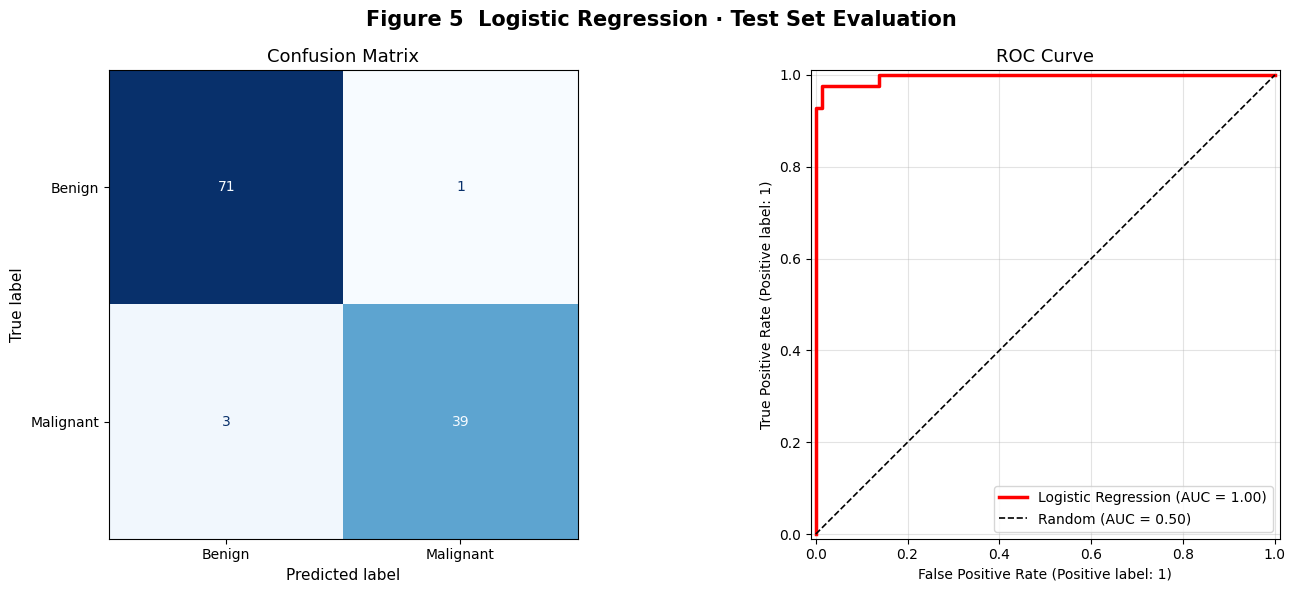

In [ ]:
# Figure 5 Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Figure 5  {best_name} · Test Set Evaluation",
             fontsize=15, fontweight="bold")

# left panel: Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(
    cmap         = "Blues",
    values_format= "d",
    ax           = axes[0],
    colorbar     = False,
)
axes[0].set_title("Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted label", fontsize=11)
axes[0].set_ylabel("True label",      fontsize=11)

# right panel: ROC curve
RocCurveDisplay.from_estimator(
    best_pipe, X_test, y_test,
    name  = best_name,
    ax    = axes[1],
    color = 'red',
    lw    = 2.5,
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1.2, label="Random (AUC = 0.50)")
axes[1].set_title("ROC Curve", fontsize=13)
axes[1].legend(fontsize=10, loc="lower right")
axes[1].grid(alpha=0.35)


plt.tight_layout()
plt.show()





## 6. Speed & Efficiency Analysis : Benchmarking



This section evaluates the computational performance of the workflow.

We focus on:

1. **Efficiency score:** ROC-AUC divided by cross-validation runtime.
2. **NumPy vs Pandas benchmark:** comparison of two ways to compute group means.
3. **Scaling simulation:** repeated sampling is used to test how aggregation time changes when the dataset size increases.


In [ ]:
# Efficiency score = ROC-AUC / CV_runtime

efficiency_df = results_df[["Model", "ROC-AUC", "CV time (s)"]].copy()
efficiency_df["AUC per second"] = (
    efficiency_df["ROC-AUC"] / efficiency_df["CV time (s)"]
)
efficiency_df = efficiency_df.sort_values("AUC per second", ascending=False)
print(efficiency_df.to_string(index=False))



              Model  ROC-AUC  CV time (s)  AUC per second
                KNN 0.985841        2.206        0.446891
Logistic Regression 0.993550        9.696        0.102470
      Random Forest 0.988024       46.914        0.021060


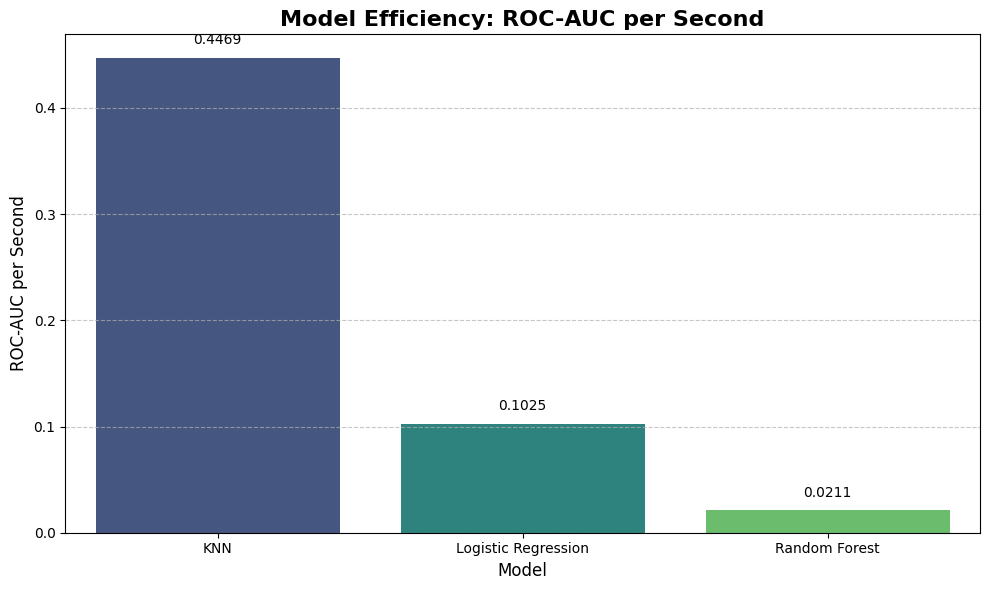

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Model', y='AUC per second', data=efficiency_df.reset_index(), palette='viridis', hue='Model', legend=False, ax=ax)
ax.set_title('Model Efficiency: ROC-AUC per Second', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('ROC-AUC per Second', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with their values
for index, row in efficiency_df.reset_index().iterrows():
    ax.text(index, row['AUC per second'] + 0.01,
            f"{row['AUC per second']:.4f}", color='black', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation: Efficiency Score

The efficiency score adds a computational perspective to the model comparison.

- **KNN** is the most efficient in this run because it combines short cross-validation time with strong ROC-AUC.
- **Logistic Regression** gives the highest predictive performance, but its repeated cross-validation time is higher than KNN.
- **Random Forest** performs well, but it is the most computationally expensive model in this workflow.

Therefore, the best choice depends on the goal: Logistic Regression is strongest for predictive performance, while KNN is strongest for speed-adjusted efficiency.


##7. NumPy vs Pandas

In [ ]:
#  NumPy vs pandas: group-mean benchmark

N_OPS = 500

# pandas groupby
t0 = time.perf_counter()
for _ in range(N_OPS):
    _ = df.groupby("diagnosis").mean()
t_pandas = (time.perf_counter() - t0) / N_OPS

# NumPy split — manually separate the two classes and call np.mean
arr    = df.drop(columns=["diagnosis"]).values
labels = df["diagnosis"].values
t0 = time.perf_counter()
for _ in range(N_OPS):
    _ = arr[labels == 0].mean(axis=0)
    _ = arr[labels == 1].mean(axis=0)
t_numpy = (time.perf_counter() - t0) / N_OPS

print(f"\n--- : Group Mean Benchmark ({N_OPS} runs each) ---")
print(f"  pandas groupby : {t_pandas*1000:.3f} ms / call")
print(f"  NumPy split    : {t_numpy*1000:.3f} ms / call")
print(f"  Speed-up       : {t_pandas/t_numpy:.1f}× faster with NumPy")


--- : Group Mean Benchmark (500 runs each) ---
  pandas groupby : 0.693 ms / call
  NumPy split    : 0.082 ms / call
  Speed-up       : 8.5× faster with NumPy


### Interpretation: NumPy vs Pandas Group Mean Benchmark

This benchmark compares a high-level Pandas operation with a direct NumPy operation.

The NumPy split is faster for this purely numerical aggregation because it avoids some of the overhead of `groupby()`. Pandas remains more convenient and readable, while NumPy can be preferable inside repeated loops or larger simulations.


## 8. Scaling simulation



The original breast cancer dataset is real biomedical data, but it is relatively small, with only 569 samples.

The goal is not to create new biological information. Instead, the original dataset is resampled with replacement to generate larger synthetic versions of the same data. This allows us to test how the workflow behaves computationally when the number of samples increases.

In this simulation, different dataset sizes are created, and the runtime of two common numerical aggregation approaches is compared:

- **Pandas groupby**, which is easy to read and useful for data analysis.
- **NumPy array operations**, which are often faster for numerical computation.




In [ ]:
# Scaling simulation: aggregation runtime on larger resampled datasets

sample_sizes = [1_000, 5_000, 10_000, 50_000, 100_000]
scaling_rows = []

for n in sample_sizes:
    # Resample the original dataset with replacement
    df_large = df.sample(n=n, replace=True, random_state=42).reset_index(drop=True)

    # Pandas groupby timing
    t0 = time.perf_counter()
    _ = df_large.groupby("diagnosis").mean()
    pandas_time = time.perf_counter() - t0

    # NumPy split timing
    arr_large = df_large.drop(columns=["diagnosis"]).values
    labels_large = df_large["diagnosis"].values

    t0 = time.perf_counter()
    _ = arr_large[labels_large == 0].mean(axis=0)
    _ = arr_large[labels_large == 1].mean(axis=0)
    numpy_time = time.perf_counter() - t0

    scaling_rows.append({
        "Sample size": n,
        "Pandas time (s)": pandas_time,
        "NumPy time (s)": numpy_time,
        "Speed-up": pandas_time / numpy_time
    })

scaling_df = pd.DataFrame(scaling_rows)
scaling_df

,Sample size,Pandas time (s),NumPy time (s),Speed-up
0,1000,0.001590,0.000369,4.309505
1,5000,0.002092,0.000796,2.627287
2,10000,0.003337,0.002167,1.540298
3,50000,0.012377,0.009974,1.240966
4,100000,0.021847,0.018530,1.178994


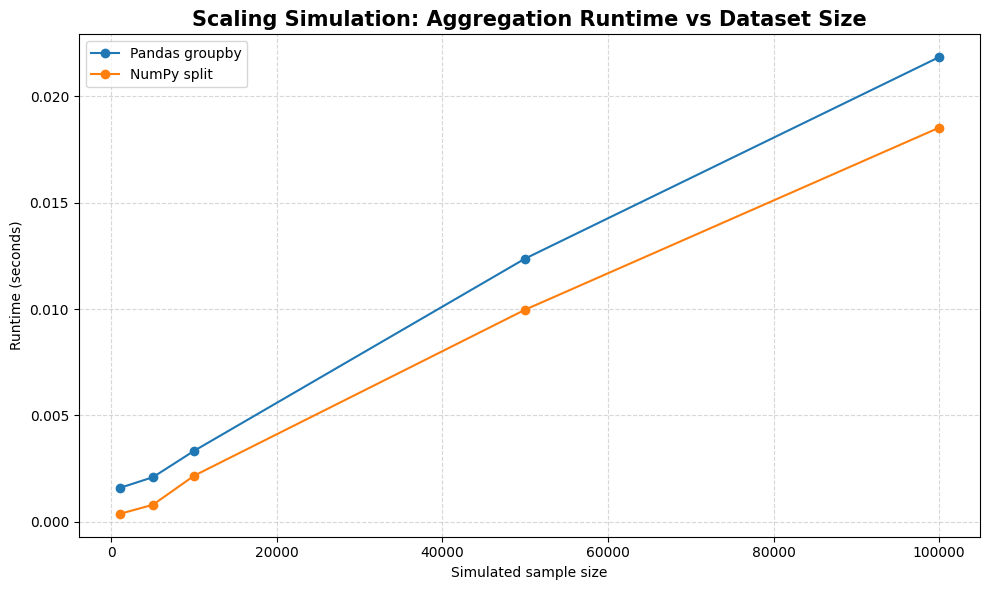

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    scaling_df["Sample size"],
    scaling_df["Pandas time (s)"],
    marker="o",
    label="Pandas groupby"
)

ax.plot(
    scaling_df["Sample size"],
    scaling_df["NumPy time (s)"],
    marker="o",
    label="NumPy split"
)

ax.set_title("Scaling Simulation: Aggregation Runtime vs Dataset Size",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Simulated sample size")
ax.set_ylabel("Runtime (seconds)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation: Scaling Simulation

As the simulated sample size increases, runtime also increases. The NumPy-based approach remains faster for repeated numerical aggregation, while Pandas remains easier to read and more convenient for general data analysis.

This simulation does not add new biological information, but it demonstrates how the workflow behaves computationally as data size increases.

## 9.  Unit Tests


In [ ]:
# Test 1 : No missing values
assert df.isna().sum().sum() == 0, "Missing values in the dataset"

# Test 2: Target variable " M or B" must be binary
assert set(y.unique()) == {0, 1}, "Target variable must be binary"

#Test 3 : Train/Test split should preserve column count
assert X_train.shape[1] == X_test.shape[1], "Train and test sets have different column counts"

#Test 4: Model prediction should match test size
assert len(y_pred) == len(y_test), "Model prediction does not match test size"

#Test 5 : Probabilities must be in [0,1]
assert (np.all(y_prob >= 0) and np.all(y_prob <= 1)), "Probabilities are not in [0,1]"

print("All  integrity checks passed!")

All  integrity checks passed!


## 10.  Conclusions

### Performance Summary

| Finding | Detail |
|---------|--------|
| **Highest predictive performance** | Logistic Regression achieved the highest cross-validation ROC-AUC in this run. |
| **Fastest / most efficient model** | KNN had the best AUC-per-second score because it was much faster during cross-validation. |
| **Least efficient model** | Random Forest performed well, but required the longest runtime. |
| **Key visual signals** | `radius_mean`, `concavity_mean`, and `concave points_mean` showed clear separation between benign and malignant samples. |

### Speed & Efficiency Summary

| Finding | Detail |
|---------|--------|
| **Model trade-off** | Logistic Regression is best for performance; KNN is best for speed-adjusted efficiency. |
| **NumPy vs Pandas** | NumPy is faster for repeated numerical aggregation, while Pandas is easier to read and organize. |
| **Scaling simulation** | Resampling the dataset to larger sizes showed how runtime increases with data size. |


### Final takeaway


This project used a real breast cancer dataset to build a transparent Scientific Python workflow for biomedical data analysis. The workflow combined data cleaning, visualization, model benchmarking, efficiency analysis, scaling simulation, and unit testing.


## 11. How to Create a GitHub Repository for this Project

The easiest way to push this notebook to GitHub is using Google Colab's built-in features:

### **Method 1: Using the Colab UI (Recommended & Easiest)**
1. Go to the top menu bar in Google Colab.
2. Click on **File** > **Save a copy in GitHub**.
3. A popup will appear asking you to authorize Google Colab to access your GitHub account (if you haven't already).
4. Once authorized, you can select an existing repository or create a **New Repository** directly from the dropdown.
5. Enter a commit message (e.g., `Initial commit: Breast Cancer Classification Workflow`) and click **OK**.

### **Method 2: Using Git Commands via Colab (Advanced)**
If you prefer to export this as a Python script or manage it via Git CLI, you will need a GitHub Personal Access Token (PAT). You can run the following commands in a new code cell, replacing `YOUR_TOKEN`, `YOUR_USERNAME`, and `YOUR_REPO` with your actual details:

```bash
!git init
!git config --global user.name "Your Name"
!git config --global user.email "your.email@example.com"
!git add .
!git commit -m "Initial commit"
!git branch -M main
!git remote add origin https://YOUR_TOKEN@github.com/YOUR_USERNAME/YOUR_REPO.git
!git push -u origin main
```